Importation des bibliothèques

Importation des bibliothèques

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Chargement des données
df = pd.read_csv("battery_health_dataset.csv")
print(df.head())

   Voltage_measured  Current_measured  Temperature_measured        SoC  \
0          3.964430         -0.912319              5.678270  97.699721   
1          3.843126         -0.995334              6.408629  92.510061   
2          3.796380         -0.995601              7.576325  87.422980   
3          3.749510         -0.995187              8.334522  82.444342   
4          3.699625         -0.995266              7.389032  77.465757   

   cycle_number battery_id        SoH  
0             1      B0047  83.626322  
1             1      B0047  83.626322  
2             1      B0047  83.626322  
3             1      B0047  83.626322  
4             1      B0047  83.626322  


Sélection des variables

In [13]:
features = [
    "Voltage_measured",
    "Current_measured",
    "Temperature_measured",
    "SoC",
    "cycle_number"
]

target = "SoH"

Normalisation Min-Max

In [17]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [18]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

df[features] = scaler_X.fit_transform(df[features])
df[[target]] = scaler_y.fit_transform(df[[target]])

Création des séquences par cycle (fenêtre glissante)

In [19]:
def create_sequences_per_cycle(df, window_size):
    
    X, y = [], []

    for battery in df["battery_id"].unique():

        df_battery = df[df["battery_id"] == battery]

        for cycle in df_battery["cycle_number"].unique():

            df_cycle = df_battery[df_battery["cycle_number"] == cycle]

            data = df_cycle[features].values
            soh_value = df_cycle[target].iloc[0]

            for i in range(len(data) - window_size):
                X.append(data[i:i+window_size])
                y.append(soh_value)

    return np.array(X), np.array(y)

Génération des données

In [20]:
window_size = 10

X, y = create_sequences_per_cycle(df, window_size)

print(X.shape)
print(y.shape)

(14590, 10, 5)
(14590,)


Séparation Train / Test

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Construction du modèle LSTM

In [22]:
model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2])),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

e:\M2\PROJET_DEEPLEARNING\LAMPADAIRE\.venv-1\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entraînement

In [23]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0100 - val_loss: 0.0080
Epoch 2/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0077 - val_loss: 0.0075
Epoch 3/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0074 - val_loss: 0.0074
Epoch 4/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0071 - val_loss: 0.0070
Epoch 5/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0069 - val_loss: 0.0075
Epoch 6/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0068 - val_loss: 0.0077
Epoch 7/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065 - val_loss: 0.0064
Epoch 8/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0061 - val_loss: 0.0077
Epoch 9/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0059 - val_loss: 0.0054
Epoch 10/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0059 - val_loss: 0.0061
Epoch 11/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0051 - val_loss: 0.0054
Epoch 12/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [24]:
# Prédiction
y_pred = model.predict(X_test)

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [25]:
# Retour à l’échelle réelle
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1,1))
y_pred_inv = scaler_y.inverse_transform(y_pred)

In [26]:
# Évaluation
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

MAE : 2.088401645022693
RMSE : 2.9422704981061094
R² : 0.8285844515650012


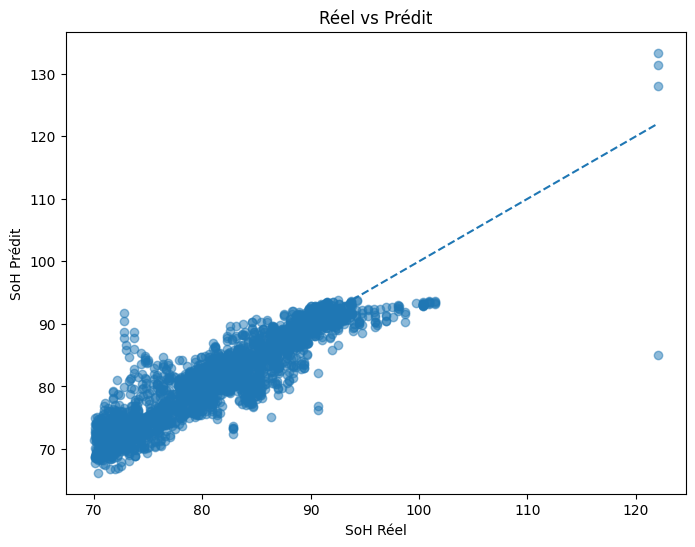

In [29]:
# Nuage de points
plt.figure(figsize=(8,6))
plt.scatter(y_test_inv, y_pred_inv, alpha=0.5)

plt.plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()],
    linestyle="--"
)

plt.xlabel("SoH Réel")
plt.ylabel("SoH Prédit")
plt.title("Réel vs Prédit")
plt.show()